# SPMe: Fit lumped thermal Cp and h from ESC data

In [1]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
import dfols
from scipy import integrate, signal, constants

%matplotlib widget
# pybamm.set_logging_level("INFO")

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


# Load current data from ESC experiment

# Set up simulation

In [5]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

# Load data

In [52]:
SOC_0 = 1
Q_nom = 4.6
t_end = 16*60

# load data import ESC data from file
raw_data = pd.read_csv("ESC_"+  str(int(SOC_0*100)) + "SOC_full.csv")
esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
esc_end = raw_data[raw_data['Time (s)']>(raw_data['Time (s)'].loc[esc_start]+t_end)].index[0]
T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
data['Current Shunt'] = -data['Current Shunt']
data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
data['Force'] = (data['Force'] - data['Force'].loc[esc_start])*9.81
df_labels = ['t', 'V', 'Temp','I', 'F']
data.set_axis(df_labels, axis=1, inplace=True)
data['I_C'] = data.I/Q_nom 
AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
data.reset_index(drop=True, inplace=True)
display(data)

,t,V,Temp,I,F,I_C,SOC
0,0.000,4.176052,24.111259,0.824988,0.000000,0.179345,0.999296
1,0.100,1.564826,24.140908,232.204691,0.603288,50.479281,0.997894
2,0.200,1.543099,24.121142,232.228600,0.698544,50.484478,0.996493
3,0.300,1.521092,24.150790,231.838083,1.174824,50.399583,0.995090
4,0.400,1.515830,24.121142,232.698815,1.174824,50.586699,0.993685
...,...,...,...,...,...,...,...
9596,959.602,0.018997,67.267536,2.120057,-125.769695,0.460882,0.294988
9597,959.702,0.018957,67.248361,2.151935,-125.388671,0.467812,0.294975
9598,959.802,0.018917,67.248361,2.068254,-125.547431,0.449620,0.294962
9599,959.902,0.018957,67.248361,2.159905,-125.737943,0.469545,0.294950


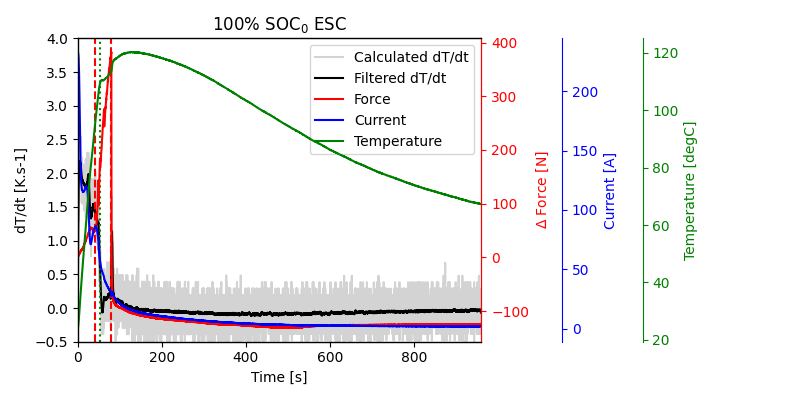

In [53]:
dTdt_data = np.diff(data.Temp)/np.diff(data.t)
dT_filtered = signal.savgol_filter(dTdt_data, 10*5,3)

# plot 
fig, ax= plt.subplots(1, 1, figsize=(8, 4), constrained_layout=True)
# ax = ax.flatten()
p1, = ax.plot(data.t[0:-1], dTdt_data, color = 'lightgrey', label = "Calculated dT/dt")
p2, = ax.plot(data.t[0:-1], dT_filtered, color = 'k', label = "Filtered dT/dt")
ax.set_ylabel("dT/dt [K.s-1]")
ax.set_xlabel("Time [s]")
ax.set_ylim([-0.5, 4])
ax.set_xlim([0,t_end])

ax1 = ax.twinx()
p3, = ax1.plot(data.t, data.F, color = 'r', label = "Force")
ax1.set_ylabel("$\Delta$ Force [N]")
ax1.yaxis.label.set_color(p3.get_color())
ax1.tick_params(axis='y', colors=p3.get_color())
ax1.spines.right.set_color(p3.get_color())

ax2 = ax.twinx()
ax2.spines.right.set_position(("axes", 1.2))
p4, = ax2.plot(data.t, data.I, color = 'b', label = "Current")
ax2.set_ylabel('Current [A]')
ax2.yaxis.label.set_color(p4.get_color())
ax2.tick_params(axis='y', colors=p4.get_color())
ax2.spines.right.set_color(p4.get_color())

ax3 = ax.twinx()
ax3.spines.right.set_position(("axes", 1.4))
p5, = ax3.plot(data.t, data.Temp, color = 'g', label = "Temperature")
ax3.set_ylabel("Temperature [degC]")
ax3.yaxis.label.set_color(p5.get_color())
ax3.tick_params(axis='y', colors=p5.get_color())
ax3.spines.right.set_color(p5.get_color())

ax.legend(handles=[p1, p2, p3, p4, p5])
plt.title(str(int(SOC_0*100)) + "% SOC$_0$ ESC")

if SOC_0 ==1:
    t_vap = [40, 80] #100%SOC
elif SOC_0 ==0.75:
    t_vap = [50, 110]#75%SOC
else: 
    t_vap = []
for t in t_vap:
    ylims = ax.get_ylim()
    ax.plot([t]*2, list(ylims), color = 'r', linestyle = '--')
    # axs.annotate('Venting', xy=(t_vap, np.diff(ylims)*0.25+ ylims[0]), rotation=-90, color = 'm')
    ax.set_ylim(ylims) # keep original limits

T_bps = [110]
for T_bp in T_bps: 
    t_boiling = data.t[(T_bp-data.Temp)<0.2].iloc[0]
    ylims = ax.get_ylim()
    ax.plot([t_boiling]*2, list(ylims), color = 'g', linestyle = ':')

plt.tight_layout()
plt.show()

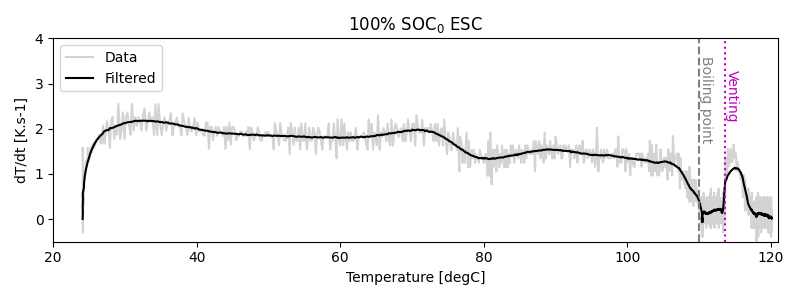

In [54]:
dTdt_data = np.diff(data.Temp)/np.diff(data.t)
dT_filtered = signal.savgol_filter(dTdt_data, 10*5,3)

# plot 
t_plot_end = 120
fig, ax= plt.subplots(1, 1, figsize=(8, 3))
ax.plot(data.Temp[data.t<t_plot_end], dTdt_data[data.t[0:-1]<t_plot_end], color = "lightgrey", label = "Data")
ax.plot(data.Temp[data.t<t_plot_end], dT_filtered[data.t[0:-1]<t_plot_end], color = "k", label = "Filtered")
ax.set_xlabel("Temperature [degC]")
ax.set_ylabel("dT/dt [K.s-1]")
ax.legend()
ax.set_ylim([-0.5, 4])
ax.set_xlim([20,121])

plt.title(str(int(SOC_0*100)) + "% SOC$_0$ ESC")

T_bps = [110]

for T in T_bps:
    ylims = ax.get_ylim()
    ax.plot([T]*2, list(ylims), color = 'grey', linestyle = '--')
    ax.annotate('Boiling point', xy=(T, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'grey')
    ax.set_ylim(ylims) # keep original limits

if SOC_0 == 1: 
    t_vent = 80
    T_vent = data.Temp[data.t == t_vent]
    ax.plot([T_vent]*2, list(ylims), color = 'm', linestyle = ':')
    ax.annotate('Venting', xy=(T_vent, np.diff(ylims)*0.6+ ylims[0]), rotation=-90, color = 'm')
plt.tight_layout()
plt.show()

In [56]:
def OCV_dim(self, soc):
    inputs = {
        "SOC": soc,
    }
    return pybamm.FunctionParameter("Cell open circuit voltage [V]", inputs)

def ocv(soc):
    p0 = np.array([0.114319142120841,  -0.663997904709863, 
            1.686768366470837,  -2.462409468590447,   2.282769243949050, 
            -1.401600551327618,   0.576551904459066,  -0.157044814050174, 
            0.027351974716897,  -0.002866912229499,   0.000171009483610,
            0.000029999998915])*1e5
    return np.polyval(p0,soc)

# Create thermal model

In [59]:
h =  19.12756173 #0.4865/0.025549 #0.009 # 10 [19.12756173  1.18576391]
Cp = 1.18576391 #219.2578/0.104/1100  # 1.25

chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)

param.update({
    "Ambient temperature [K]":T_amb_0 + 273.15,
    "Initial temperature [K]": T_amb_0 + 273.15,
    "Negative tab width [m]":2.5e-2,
    "Positive tab width [m]":2.5e-2, 
    "Edge heat transfer coefficient [W.m-2.K-1]":h,
    "Total heat transfer coefficient [W.m-2.K-1]":h,
    "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Cell open circuit voltage [V]": ocv,
}, check_already_exists = False)

# Dimensional 

## Check that model runs

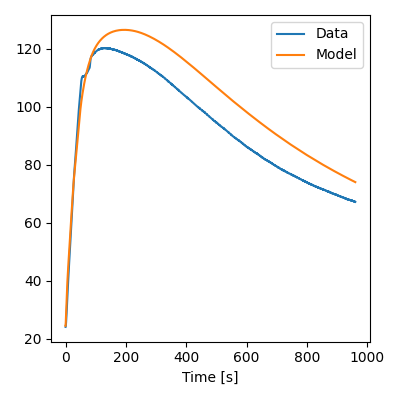

In [58]:
def sim_thermal(h,Cp):    
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)
    # Define input and output
    Q_vol_av = pybamm.Variable("Volume-averaged total heating [W]")
    T_vol_av= pybamm.Variable("Volume-averaged cell temperature [K]")

    # Init model and variables
    model = pybamm.BaseModel()
    model.variables = {
        "Volume-averaged total heating [W]": Q_vol_av, 
        "Volume-averaged cell temperature [K]": T_vol_av,
    }
    model.external_variables = [Q_vol_av]

    # Set up parameters
    thermal = pybamm.thermal_parameters
    liion = pybamm.LithiumIonParameters()
    cell_surface_area = param.evaluate(liion.A_cooling) # [m2]
    cell_volume = param.evaluate(liion.V_cell) # [m3]
    h_total = param.evaluate(thermal.h_total_dim) # [W.m-2.K-1]
    rho = param.evaluate(thermal.rho_eff_dim(T_vol_av)) # [J.m-3.K-1]
    T_amb = T_amb_0+273.15
    total_cooling_coefficient = -h_total

    # RHS
    model.rhs = {
        T_vol_av: 1/(rho * cell_volume)* Q_vol_av + total_cooling_coefficient * cell_surface_area / (rho * cell_volume) * (T_vol_av - T_amb)
    }
    # print(rho * cell_volume)
    # print(total_cooling_coefficient * cell_surface_area)
    # set initial conditions
    T_init = T_amb
    model.initial_conditions = {T_vol_av: pybamm.Scalar(T_init)}

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # set Q as external variable
    Q_data = data.I*(ocv(data.SOC)-data.V)

    # solve
    sim = pybamm.Simulation(model)
    for i,(t, q) in enumerate(zip(data.t[0:-1], Q_data[0:-1])):
        dt = data.t[i+1]-data.t[i]
        external_variables = {"Volume-averaged total heating [W]": q}
        sim.step(dt, external_variables=external_variables)
    
    return sim

sim = sim_thermal(15, 1.18576391) #19.12756173,  1.18576391
solution = sim.solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states
T = solution["Volume-averaged cell temperature [K]"].entries-273.15  
Q = solution["Volume-averaged total heating [W]"].entries

# plot 
fig, ax= plt.subplots(1, 1, figsize=(4, 4))
ax.plot(data.t, data.Temp)
# ax.plot(data.t, Q_data)
ax.plot(t_sol, T)
ax.set_xlabel("Time [s]")
ax.legend(["Data", "Model"], loc="best")

plt.tight_layout()
plt.show()


## Set up loss function

In [13]:
def loss_T(k:np.ndarray): 
    h = k[0]
    Cp = k[1]
    solution = sim_thermal(h,Cp).solution

    # calculate squared sum for rest period
    T = solution['Volume-averaged cell temperature [K]'] 
    # loss_T = np.sum(np.square(data.Temp- (T(data.t)-273.15)))
    # loss_T = np.linalg.norm(data.Temp- (T(data.t)-273.15))
    loss_T = np.linalg.norm(np.diff(data.Temp) - np.diff(T(data.t)))
    return np.array([loss_T])

# test function
print(loss_T(np.array([20, 1])))

[2.36759024]


## Fit thermal parameters

In [ ]:
# # define sim parameters 
# # Fit thermal params
# [19.12756173  1.18576391]
k0 = np.array([5,1]) #[h, k_cp] cp = cp0*k_cp
lb = np.array([5,0.1])
ub = np.array([50,2])
k = dfols.solve(loss_T, k0, bounds = (lb,ub), rhoend=1e-4)

# update fitted thermal params
h = k.x[0]
Cp = k.x[1]
solution = sim_thermal(h,Cp)
solution = sim_thermal(h,Cp).solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states

print(k.x)


## Plot data vs model

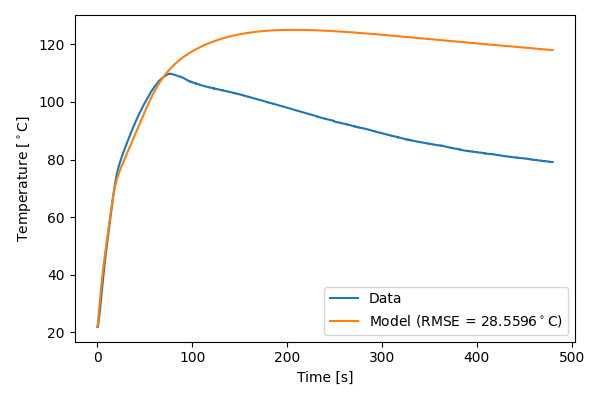

In [ ]:
# plot 
T = solution["Volume-averaged cell temperature [K]"].entries-273.15  
Q = solution["Volume-averaged total heating [W]"].entries

rmse_T = np.sqrt(np.mean(np.square(data.Temp- T)))

solution = sim_thermal(h,Cp).solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states
T = solution["Volume-averaged cell temperature [K]"].entries-273.15  
Q = solution["Volume-averaged total heating [W]"].entries


fig, ax= plt.subplots(1, 1, figsize=(6, 4))
ax.plot(data.t, data.Temp, label = "Data")
ax.plot(t_sol, T, label = "Model (RMSE = " + str(np.round(rmse_T, 4)) + '$^\circ$C)' )
ax.set_xlabel("Time [s]")
ax.set_ylabel("Temperature [$^\circ$C]")
ax.legend()

plt.tight_layout()
plt.show()

# Dimensional with latent heat of vaporization

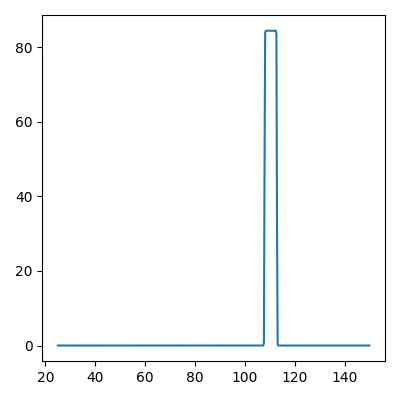

In [11]:
def P_sat(T):
    P_dmc = 10**(6.4338-1413.0/(T-44.25))
    P_ec = 10**(6.4897-1836.57/(T-102.23))
    P = 0.3*P_ec + 0.7*P_dmc 
    return P

electrolyte_boiling_pt = 0.3*110+0.7*107
h_vap = .3*60+.7*34.6
x = np.linspace(25,150, 500)
y = ((np.tanh(10*(x-electrolyte_boiling_pt))+1)*(-np.tanh(10*(x-(electrolyte_boiling_pt+5)))+1))*h_vap/2

# plot 
fig, ax= plt.subplots(1, 1, figsize=(4, 4))
ax.plot(x,y)

plt.tight_layout()
plt.show()


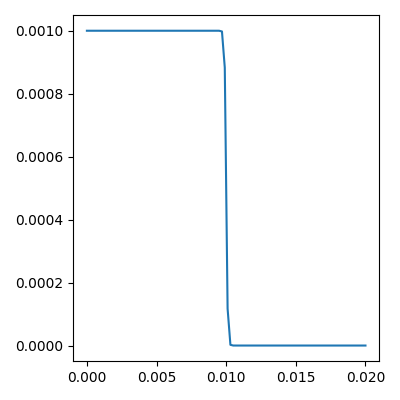

In [12]:
thermal = pybamm.thermal_parameters
total_electrolyte_mass = 10e-3
M_e = param.evaluate(thermal.M_e)
m_e_loss = np.linspace(0, total_electrolyte_mass*2, 100)
m_e_loss_rate = 1e-3/2*(-np.tanh((m_e_loss-total_electrolyte_mass)*10000)+1)

# plot 
fig, ax= plt.subplots(1, 1, figsize=(4, 4))
ax.plot(m_e_loss,m_e_loss_rate)

plt.tight_layout()
plt.show()

In [15]:
def sim_thermal_vap(h,Cp):    
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Electrolyte boiling point [K]": (0.3*110+0.7*107) + 273.15,
        "Electrolyte heat of vaporization [J.mol-1]": (.3*60+.7*34.6)*1000, 
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)
    
    # Define input and output
    Q_vol_av = pybamm.Variable("Volume-averaged total heating [W]")
    T_vol_av = pybamm.Variable("Volume-averaged cell temperature [K]")
    x_sei = pybamm.Variable("Fraction of Li in SEI")
    delta_sigma = pybamm.Variable("Cell expansion stress [kPa]")

    # Init model and variables
    model = pybamm.BaseModel()
    model.variables = {
        "Volume-averaged total heating [W]": Q_vol_av, 
        "Volume-averaged cell temperature [K]": T_vol_av,
        "Fraction of Li in SEI": x_sei,
        "Cell expansion stress [kPa]": delta_sigma,
    }
    model.external_variables = [Q_vol_av]

    # Set up parameters
    thermal = pybamm.thermal_parameters
    liion = pybamm.LithiumIonParameters()
    T_amb = T_amb_0+273.15

    # SEI DECOMPOSITION SUBMODEL
    k_b = pybamm.Scalar(constants.k)
    rho_n_dim = param["Negative electrode density [kg.m-3]"]
    r_sei_dimensional = (
    -param.evaluate(thermal.A_sei)* x_sei* pybamm.exp(-param.evaluate(thermal.E_sei) / (k_b * T_vol_av)))  # units 1/s
    m_an = rho_n_dim * param.evaluate(liion.L_y) * param.evaluate(liion.L_z) * param.evaluate(liion.n.L)
    Q_exo_sei = -m_an * param.evaluate(thermal.h_sei) * r_sei_dimensional 

    model.variables.update({
            "SEI decomposition reaction rate [s-1]": r_sei_dimensional,
            "SEI decomposition heating [W]": Q_exo_sei,
        })
    
    # VENTING SUBMODEL
    m_an = param.evaluate(thermal.m_an)
    x_sei_0 = param.evaluate(thermal.x_sei_0)
    M_C6 = param.evaluate(thermal.M_an)
    V_head_0 = param.evaluate(thermal.V_head_0)
    A_surf = param.evaluate(thermal.A_surf)
    L = param.evaluate(thermal.L_poron)
    E = param.evaluate(thermal.E_poron)
    alpha_cell = param.evaluate(thermal.alpha_cell)
    P_crit = param.evaluate(thermal.P_crit)
    sigma_0 = param.evaluate(thermal.sigma_0)
    P_atm = param.evaluate(thermal.P_atm)
    M_e = param.evaluate(thermal.M_e)
    # rho_e = thermal.rho_e
    # m_e_0 = thermal.m_e_0
    delta_d = L/E*delta_sigma
    delta_T = T_vol_av-T_amb
    V_head = V_head_0 + A_surf*(delta_d-alpha_cell*delta_T)   
    P_sat_e = P_sat(T_vol_av) 
    P_sat_ref = P_sat(T_amb)
    n_CO2 = m_an*(x_sei_0 - x_sei)/(2*M_C6)
    P_CO2 = (n_CO2*constants.R*T_vol_av/V_head/1000) #kPa
    P_total = P_CO2 + P_sat_e 
    n_e_vap = P_sat_e*1000*V_head/(constants.R*T_vol_av) - P_sat_ref*1000*V_head_0/(constants.R*T_amb)
    m_e_loss = pybamm.maximum(n_e_vap*M_e,0)  # [kg]

    model.variables.update({
        "Mass of electrolyte lost [kg]": m_e_loss,
        "Moles of electrolyte lost [mol]": n_e_vap,
    })

    # HEAT OF VAPORIZATION
    cell_surface_area = param.evaluate(liion.A_cooling) # [m2]
    cell_volume = param.evaluate(liion.V_cell) # [m3]
    h_total = param.evaluate(thermal.h_total_dim) # [W.m-2.K-1]
    rho = param.evaluate(thermal.rho_eff_dim(T_vol_av)) # [J.m-3.K-1]
    total_cooling_coefficient = -h_total
    electrolyte_boiling_pt = 110 + 273.15
    h_vap = (.3*60+.7*34.6)*1000
    # H_vap = (pybamm.tanh(10*(T_vol_av-(electrolyte_boiling_pt)))+1)*h_vap/2 # "turn on" vaporization if T is above the boiling pt
    H_vap = h_vap # "turn on" vaporization if T is above the boiling pt

    total_electrolyte_mass = 1e-3 #[kg]
    M_e = param.evaluate(thermal.M_e)
    # m_e_loss_rate = (-pybamm.tanh(10*(T_vol_av-(electrolyte_boiling_pt+15)))+1)
    # n_e_loss_rate = pybamm.Symbol(n_e_vap).diff()
    # Q_cool_vap = -H_vap*pybamm.maximum(1e-3 - m_e_loss,0)/M_e    Q_cool_vap = -H_vap*pybamm.maximum(1e-3 - m_e_loss,0)/M_e
    dTdt = (Q_vol_av + total_cooling_coefficient * cell_surface_area* (T_vol_av - T_amb)) / (rho * cell_volume)
    # dndt = -(P_sat_e*1000*V_head/(constants.R*T_vol_av))**-2*dTdt
    # dndt = pybamm.Symbol.diff(n_e_vap,pybamm.t) # error about derivative of variable in rhs
    dndt = (P_sat_e*1000*V_head/(constants.R*T_vol_av))*dTdt

    # Q_cool_vap = -H_vap*m_e_loss/M_e
    Q_cool_vap = -H_vap*pybamm.maximum(dndt,0)

    model.variables.update({
        "Total heat of vaporization [W]": Q_cool_vap,
    })

    # RHS
    model.rhs = {
        T_vol_av: (Q_vol_av + total_cooling_coefficient * cell_surface_area* (T_vol_av - T_amb) + Q_cool_vap + Q_exo_sei) / (rho * cell_volume),
        x_sei: r_sei_dimensional,
        # m_e_loss: m_e_loss_rate,
    }
    # print(rho * cell_volume)
    # print(total_cooling_coefficient * cell_surface_area)
    # set initial conditions
    T_init = T_amb
    model.initial_conditions = {
        T_vol_av: pybamm.Scalar(T_init),
        x_sei: param.evaluate(thermal.x_sei_0),
        delta_sigma: pybamm.Scalar(0),
        # m_e_loss:pybamm.Scalar(0),
        }

    model.algebraic = {
        delta_sigma: delta_sigma - pybamm.maximum(P_total-sigma_0-P_atm, E*alpha_cell*delta_T/L),
        }
    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # set Q as external variable
    Q_data = data.I*(ocv(data.SOC)-data.V)

    # solve
    sim = pybamm.Simulation(model)
    for i,(t, q) in enumerate(zip(data.t[0:-1], Q_data[0:-1])):
        dt = data.t[i+1]-data.t[i]
        external_variables = {"Volume-averaged total heating [W]": q}
        sim.step(dt, external_variables=external_variables)
    
    return sim

# sim_vap = sim_thermal_vap(19.12756173,  1.18576391)
h = 19.12756173-3
Cp = 1
# sim = sim_thermal(h,  Cp)
# solution = sim.solution
# t, y = solution.t, solution.y  # get solution times and states
# T = solution["Volume-averaged cell temperature [K]"].entries-273.15 
# Q = solution["Volume-averaged total heating [W]"].entries

sim_vap = sim_thermal_vap(h,Cp)
solution_vap = sim_vap.solution
t_vap, y_vap = solution_vap.t, solution_vap.y  # get solution times and states
T_vap = solution_vap["Volume-averaged cell temperature [K]"].entries-273.15  
Q_vap = solution_vap["Volume-averaged total heating [W]"].entries


NameError: name 't' is not defined

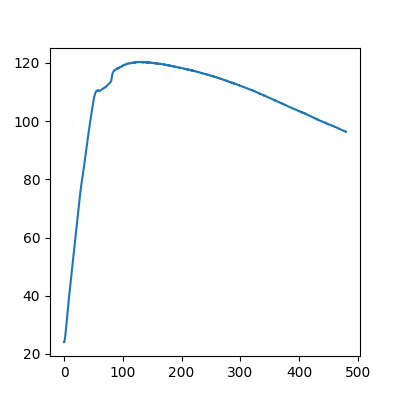

In [14]:
# plot 
Q_data = data.I*(ocv(data.SOC)-data.V)
fig, ax= plt.subplots(1, 1, figsize=(4, 4))
ax.plot(data.t, data.Temp, label = "Data")
ax.plot(t, T, label = "Nominal")
ax.plot(t_vap, T_vap, label = "with vaporization")

ax1 = plt.twinx(ax)
m_e_loss = solution_vap["Mass of electrolyte lost [kg]"].entries*1000 
H_vap_total = solution_vap["Total heat of vaporization [W]"].entries
# ax1.plot(t_sol, m_e_loss, color="grey", linestyle = '--')
ax1.plot(t_sol, H_vap_total, color="grey", linestyle = '--', label = "$Q_{vap,total}$")
# ax1.plot(data.t, Q_data, color="m", linestyle = '--', label = "$Q_{ohmic}$")

ax.set_xlabel("Time [s]")
ax.legend(loc="right")
ax1.legend(loc="best")

plt.tight_layout()
plt.show()

# Nondimensional

## Check that model runs

In [77]:
chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)

param.update({
    "Ambient temperature [K]":T_amb_0 + 273.15,
    "Initial temperature [K]": T_amb_0 + 273.15,
    "Negative tab width [m]":2.5e-2,
    "Positive tab width [m]":2.5e-2,
    "Edge heat transfer coefficient [W.m-2.K-1]":h,
    "Total heat transfer coefficient [W.m-2.K-1]":h,
    "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Cell open circuit voltage [V]": ocv,
    "Cell capacity [A.h]": 4.6, #nominal
    "Typical current [A]": 4.6,
    "Negative electrode thickness [m]":62E-06*4.2/5,
    "Positive electrode thickness [m]":67E-06*4.2/5,
}, check_already_exists = False)
liion = pybamm.LithiumIonParameters()
tau_discharge = param.evaluate(liion.tau_discharge)
tau_th_yz = param.evaluate(liion.tau_th_yz)

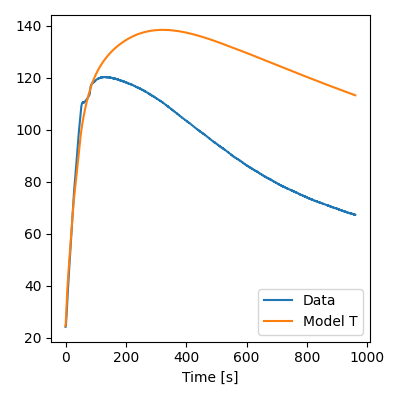

In [79]:
def sim_thermal_nondim(h,Cp):    
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)

    # Define input and output
    Q_vol_av = pybamm.Variable("Volume-averaged total heating")
    T_vol_av= pybamm.Variable("Volume-averaged cell temperature")

    # Init model and variables
    liion = pybamm.LithiumIonParameters()
    model = pybamm.BaseModel()
    Delta_T = param.evaluate(liion.Delta_T)
    T_ref = param.evaluate(liion.T_ref)
    tau_discharge = param.evaluate(liion.tau_discharge)
    tau_th_yz = param.evaluate(liion.tau_th_yz)
    model.timescale = pybamm.Scalar(tau_discharge)
    model.variables = {
        "Volume-averaged total heating": Q_vol_av, 
        "Volume-averaged cell temperature": T_vol_av,
        "Volume-averaged cell temperature [K]": Delta_T * T_vol_av + T_ref,
    }
    model.external_variables = [Q_vol_av]

    # Set up parameters
    # thermal = pybamm.thermal_parameters
    delta = param.evaluate(liion.delta) #self.L_x / self.L_z
    cell_surface_area = param.evaluate(liion.a_cooling) #self.A_cooling / (self.L_z ** 2)
    cell_volume = param.evaluate(liion.v_cell) # self.V_cell / (self.L_x * self.L_z ** 2)
    h_total = param.evaluate(liion.h_total) # self.h_total_dim * self.geo.L_x / self.lambda_eff_dim_ref
    rho = param.evaluate(liion.rho(T_vol_av)) # Dimensionless effective density? self.rho_dim(T_dim) * self.c_p_dim(T_dim) / self.main_param.rho_eff_dim_ref
    T_amb = param.evaluate(liion.T_amb(0)) # (self.T_amb_dim(t) - self.T_ref) / self.Delta_T
    total_cooling_coefficient = (
        -h_total
        * cell_surface_area
        / cell_volume
        / (delta ** 2))
    B = param.evaluate(liion.B) #self.B = (self.i_typ* self.R* self.T_ref* self.tau_th_yz/ (self.therm.rho_eff_dim_ref * self.F * self.Delta_T * self.L_x))
    C_th = param.evaluate(liion.tau_th_yz)/param.evaluate(liion.tau_discharge) # self.tau_th_yz / self.timescale
    Q_scale = param.evaluate(liion.i_typ) * param.evaluate(liion.potential_scale) / param.evaluate(liion.L_x)


    model.variables.update({
    "Volume-averaged total heating [W.m-3]": Q_vol_av * Q_scale,
    })

    # RHS
    model.rhs = {
        T_vol_av: (
            B * Q_vol_av + total_cooling_coefficient * (T_vol_av - T_amb)
        )/ (C_th * rho)
    }
    
    # set initial conditions
    T_init = param.evaluate(liion.T_init)
    model.initial_conditions = {T_vol_av: pybamm.Scalar(T_init)}

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # set Q as external variable
    Q_data = data.I*(ocv(data.SOC)-data.V)

    # solve
    sim = pybamm.Simulation(model)
    V_cell_norm = param.evaluate(liion.L_x) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) 
    for i,(t, q) in enumerate(zip(data.t[0:-1], Q_data[0:-1])):
        dt = data.t[i+1]-data.t[i]
        external_variables = {"Volume-averaged total heating": q/V_cell_norm/Q_scale/C_th}
        sim.step(dt, external_variables=external_variables)
    return sim

sim = sim_thermal_nondim(19.12756173, 1.18576391) #19.12756173,  1.18576391
solution = sim.solution
liion = pybamm.LithiumIonParameters()
tau_discharge = param.evaluate(liion.tau_discharge)
tau_th_yz = param.evaluate(liion.tau_th_yz)
t_sol, y_sol = solution.t*tau_discharge, solution.y  # get solution times and states
T = solution["Volume-averaged cell temperature [K]"].entries - 273.15
# Q = solution["Volume-averaged total heating"].entries

# plot 
Q_data = data.I*(ocv(data.SOC)-data.V)
fig, ax= plt.subplots(1, 1, figsize=(4, 4))
V_cell_norm = param.evaluate(liion.L_x) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) 
ax.plot(data.t, data.Temp, label = "Data")
# ax.plot(data.t, Q_data/V_cell_norm/Q_scale,label = "Data")
# ax.plot(t_sol, Q, linestyle = '--',label =  "Model Q")
ax.plot(t_sol, T, label =  "Model T")
ax.set_xlabel("Time [s]")
ax.legend()

plt.tight_layout()
plt.show()


## Set up loss function

In [80]:
def loss_T_nondim(k:np.ndarray): 
    h = k[0]
    Cp = k[1]
    solution = sim_thermal_nondim(h,Cp).solution

    # calculate squared sum for rest period
    T = solution['Volume-averaged cell temperature [K]'] 
    # loss_T = np.sum(np.square(data.Temp- (T(data.t)-273.15)))
    # loss_T = np.linalg.norm(data.Temp- (T(data.t)-273.15))
    liion = pybamm.LithiumIonParameters()
    tau_discharge = param.evaluate(liion.tau_discharge)
    loss_T = np.linalg.norm(np.diff(data.Temp[0:-1]) - np.diff(T(data.t[0:-1]))) # avoid nan
    return np.array([loss_T])

# test function
print(loss_T_nondim(np.array([20, 1])))

[2.55745409]


## Fit thermal parameters

In [68]:
# # define sim parameters 
# # Fit thermal params
# [7.68532559 1.27182189]
k0 = np.array([1,1]) #[h, k_cp] cp = cp0*k_cp
lb = np.array([1,0.1])
ub = np.array([50,2])
k = dfols.solve(loss_T_nondim, k0, bounds = (lb,ub), rhoend=1e-2)

# update fitted thermal params
h = k.x[0]
Cp = k.x[1]
solution = sim_thermal_nondim(h,Cp)
solution = sim_thermal_nondim(h,Cp).solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states

print(k.x)


KeyboardInterrupt: 

## Plot data vs model

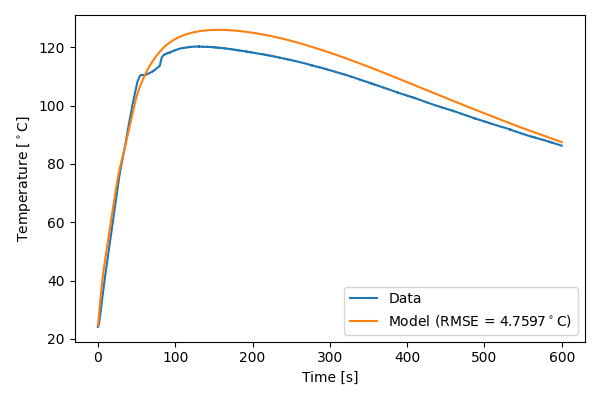

In [44]:
# plot 
rmse_T = np.sqrt(np.mean(np.square(data.Temp- T)))

# solution = sim_thermal_nondim(h,Cp).solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states
T = solution["Volume-averaged cell temperature [K]"].entries-273.15  
# Q = solution["Volume-averaged total heating [W]"].entries


fig, ax= plt.subplots(1, 1, figsize=(6, 4))
ax.plot(data.t, data.Temp, label = "Data")
ax.plot(t_sol*tau_discharge, T, label = "Model (RMSE = " + str(np.round(rmse_T, 4)) + '$^\circ$C)' )
ax.set_xlabel("Time [s]")
ax.set_ylabel("Temperature [$^\circ$C]")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
h =  10 #0.4865/0.025549 #0.009 # 10
Cp = 0.8 #219.2578/0.104/1100  # 1.25

options = {
    "thermal": "lumped",
#         "side reactions": "decomposition",
    "external submodels": ["thermal"]
}
model = pybamm.lithium_ion.SPMe(options = options)
chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)
    
param.update({
    "Ambient temperature [K]":T_amb + 273.15,
    "Initial temperature [K]": 296.7,
    "Negative tab width [m]":2.5e-2,
    "Positive tab width [m]":2.5e-2,
    "Negative current collector surface heat transfer coefficient [W.m-2.K-1]": h,  
    "Positive current collector surface heat transfer coefficient [W.m-2.K-1]": h,  
    "Negative tab heat transfer coefficient [W.m-2.K-1]":h,  
    "Positive tab heat transfer coefficient [W.m-2.K-1]":h,  
    "Edge heat transfer coefficient [W.m-2.K-1]":h,
    "Total heat transfer coefficient [W.m-2.K-1]":h,
    "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
}, check_already_exists = False)
    
t_eval = np.arange(0, 8*60,0.1)
solver = pybamm.CasadiSolver(mode="safe") 
sim = pybamm.Simulation(model, parameter_values = param, solver=solver) 
solution = sim.solve( initial_soc=SOC_0, t_eval = t_eval)


C:\Users\Vivian\AppData\Local\Temp\ipykernel_9768\421229502.py:22: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)


# Set up loss function

In [ ]:
def simulate_esc_T(k:np.ndarray): 
    h = k[0]
    Cp = k[1]
    param.update({
        "Negative current collector surface heat transfer coefficient [W.m-2.K-1]": h,  
        "Positive current collector surface heat transfer coefficient [W.m-2.K-1]": h,  
        "Negative tab heat transfer coefficient [W.m-2.K-1]":h,  
        "Positive tab heat transfer coefficient [W.m-2.K-1]":h,  
        "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        })
    sim = pybamm.Simulation(model, parameter_values = param) 
    solution = sim.solve( initial_soc=soc, t_eval = t_eval)

    # calculate rmse for rest period
    T = solution['Volume-averaged cell temperature [K]'] 
    t_error = data.t[(data.index>esc_start) & (data.t<t_eval[-1])].to_numpy() 
    rmse_T = np.sum(np.square(data.Temp[(data.index>esc_start) & (data.t<t_eval[-1])]- (T(t_error)-273.15)))

    return np.array([rmse_T])

# test function
print(simulate_esc_T(np.array([0.7, 1.5])))

[9395935.6284587]


# Plotting function

In [ ]:
def plot_data(data, solutions, labels = []):
    fig, ax = plt.subplots(1,3, figsize=(8,4), sharex=True)
    ax = ax.flatten()
    linestyles = ['-','--',':','.-']*2

    t = data.t/60
    xlabel = "Time [min]"
    data_color = 'k'
    ax[0].plot(t,data.I_C, label='Data', color = data_color)
    ax[0].set_xlabel(xlabel)
    ax[0].set_ylabel('C-rate')


    ax[2].plot(t, data.V,color = data_color)
    ax[2].set_xlabel(xlabel)
    ax[2].set_ylabel('Terminal voltage [V]')

    ax[1].plot(t, data.Temp, color = data_color)
    ax[1].set_xlabel(xlabel)
    ax[1].set_ylabel('Temperature [$^\circ$C]')

    # ax[3].plot(t, data.SOC, color = data_color)
    # ax[3].set_xlabel(xlabel)
    # ax[3].set_ylabel('SOC')

    sim_colors = ['r','g','b','m']*2
    for i,solution in enumerate(solutions):
        t = solution["Time [s]"].entries
        x = solution["x [m]"].entries[:, 0]
        I = solution['C-rate']
        V = solution['Terminal voltage [V]']
        T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
        soc = solution['R-averaged negative particle concentration']

        x_plot = t/60
        ax[0].plot(x_plot, I(t), linestyle=':',color = sim_colors[i])
        ax[2].plot(x_plot, V(t), linestyle=':',color = sim_colors[i])
        ax[1].plot(x_plot, T,linestyle=':',color = sim_colors[i])  # can evaluate at arbitrary x (single representative particle)
        # ax[3].plot(x_plot, soc(t=t, x=x[-1]),linestyle=':',color = sim_colors[i])  # can evaluate at arbitrary x (single representative particle)


    plt.tight_layout()
    plt.show()
    plt.xlim([t_eval[0],t_eval[-1]/60])



# Fit thermal parameters

At t = 0.00471011 and h = 4.30955e-011, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 0 and h = 5.30026e-014, the error test failed repeatedly or with |h| = hmin.
At t = 0 and h = 6.50569e-014, the error test failed repeatedly or with |h| = hmin.
At t = 0 and h = 6.51279e-014, the error test failed repeatedly or with |h| = hmin.
At t = 0.00555595 and h = 5.02478e-011, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 0 and h = 6.50569e-014, the error test failed repeatedly or with |h| = hmin.
At t = 0 and h = 6.51279e-014, the error test failed repeatedly or with |h| = hmin.
At t = 0 and h = 6.50569e-014, the error test failed repeatedly or with |h| = hmin.
At t = 0 and h = 6.51279e-014, the error test failed repeatedly or with |h| = hmin.


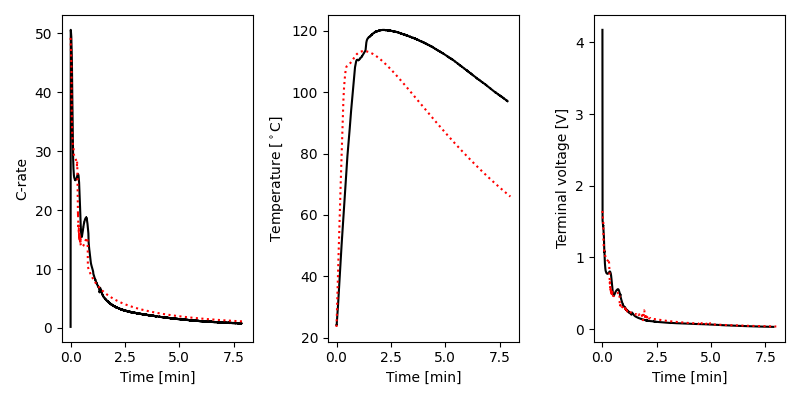

In [ ]:
# define sim parameters
SOC_0 = 1
# data_current = data[['t','I']].to_numpy()
    
# Fit thermal params
k0 = np.array([0.72753047-0.05, 1.51997699])
lb = np.array([0.5]*2)
ub = np.array([5]*2)
k = dfols.solve(simulate_esc_T, k0, bounds = (lb,ub), rhoend=1e-2)

# simulate with k
solutions = []

# fitted
h = k.x[0]
Cp = k.x[1]
param.update({
    "Negative current collector surface heat transfer coefficient [W.m-2.K-1]": h,  
    "Positive current collector surface heat transfer coefficient [W.m-2.K-1]": h,  
    "Negative tab heat transfer coefficient [W.m-2.K-1]":h,  
    "Positive tab heat transfer coefficient [W.m-2.K-1]":h,  
    "Edge heat transfer coefficient [W.m-2.K-1]":h,
    "Total heat transfer coefficient [W.m-2.K-1]":h,
    "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    })
solver = pybamm.CasadiSolver(mode="safe",dt_max = 1) #dt_max = 1e-3
sim = pybamm.Simulation(model, parameter_values = param)
solution = sim.solve( initial_soc=SOC_0, t_eval = t_eval)
solutions.append(solution)

# plot with 
plot_data(data,solutions)

In [ ]:
k.x

array([0.5, 0.5])

In [ ]:
display([k for k in model.variables.keys()])

['Time',
 'Time [s]',
 'Time [min]',
 'Time [h]',
 'x',
 'x [m]',
 'x_n',
 'x_n [m]',
 'x_s',
 'x_s [m]',
 'x_p',
 'x_p [m]',
 'r_p',
 'r_p [m]',
 'r_n',
 'r_n [m]',
 'Current density variable',
 'Total current density',
 'Total current density [A.m-2]',
 'Current [A]',
 'C-rate',
 'Discharge capacity [A.h]',
 'Discharge energy [W.h]',
 'Throughput energy [W.h]',
 'Throughput capacity [A.h]',
 'Porosity',
 'Separator porosity',
 'Positive electrode porosity',
 'X-averaged separator porosity',
 'X-averaged positive electrode porosity',
 'Negative electrode porosity',
 'X-averaged negative electrode porosity',
 'Leading-order porosity',
 'Leading-order separator porosity',
 'Leading-order positive electrode porosity',
 'Leading-order x-averaged separator porosity',
 'Leading-order x-averaged positive electrode porosity',
 'Leading-order negative electrode porosity',
 'Leading-order x-averaged negative electrode porosity',
 'Porosity change',
 'Separator porosity change',
 'Positive elect

Some of the output variables are defined over space as well as time. Once option to visualise these variables is to use the `interact` slider widget. Below we plot the negative/positive particle concentration over $r$, using a slider to change the current time point

The QuickPlot class can be used to plot the common set of useful outputs which should give you a good initial overview of the model. The method `Quickplot.dynamic_plot` employs the slider widget.  

interactive(children=(FloatSlider(value=0.0, description='t', max=1170.1690019126265, step=11.701690019126266)…

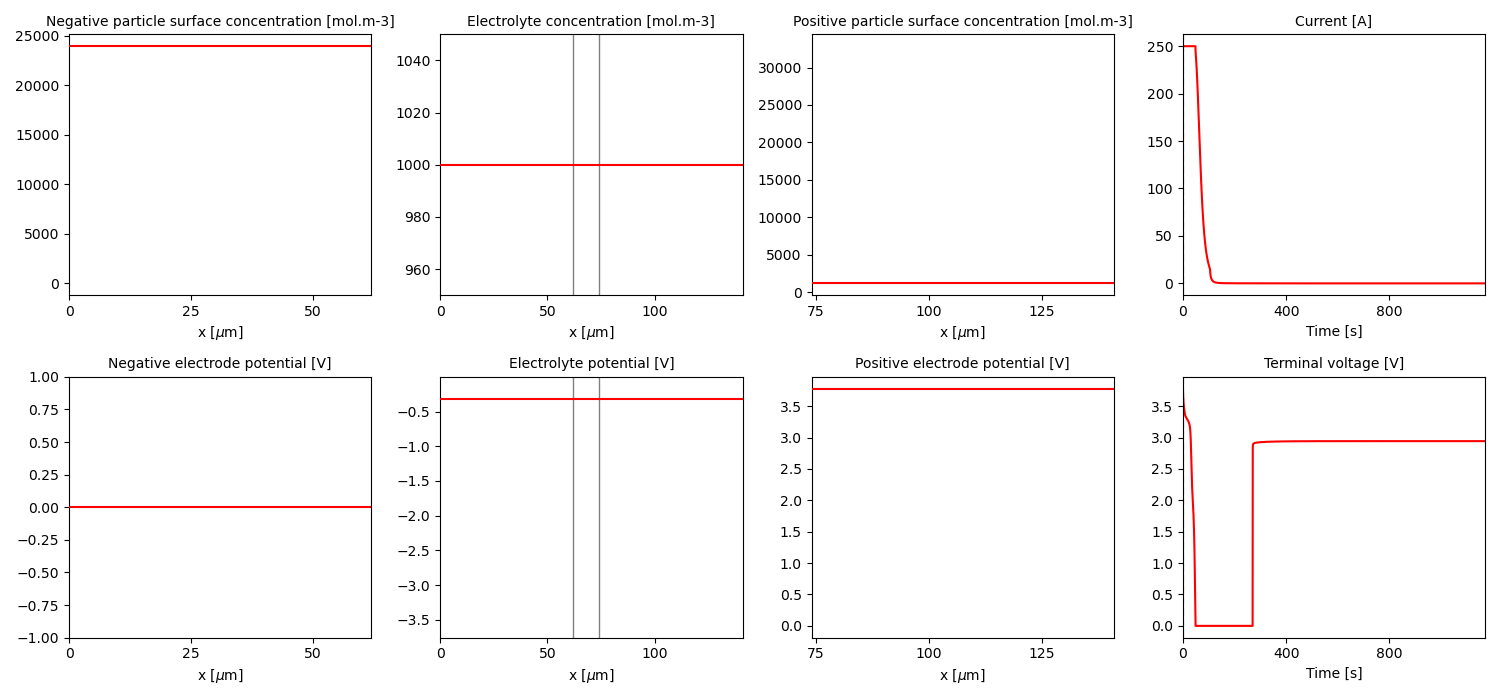

In [ ]:
solution = solutions[0]
quick_plot = pybamm.QuickPlot(solution)
quick_plot.dynamic_plot();

## Dimensionless Parameters

In the table below, we provide the dimensionless parameters in the SPM in terms of the dimensional parameters in LCO.csv. We use a superscript * to indicate dimensional quantities. 

| Parameter                 | Expression                              |Interpretation                             |
|:--------------------------|:----------------------------------------|:------------------------------------------|
| $L_{\text{k}}$            | $L_{\text{k}}^*/L^*$                    | Ratio of region thickness to cell thickness|
|$\mathcal{C}_{\text{k}}$   | $\tau_{\text{k}}^*/\tau_{\text{d}}^*$   | Ratio of solid diffusion and discharge timescales |
|$\mathcal{C}_{\text{r,k}}$ |$\tau_{\text{r,k}}^*/\tau_{\text{d}}^*$  |Ratio of reaction and discharge timescales|
|$a_{R, \text{k}}$             |$a_{\text{k}}^* R_{\text{k}}^*$          | Product of particle radius and surface area to volume ratio|
|$\gamma_{\text{k}}$        |$c_{\text{k,max}}^*/c_{\text{n,max}}^*$  |Ratio of maximum lithium concentrations in solid|

In [ ]:
c_s_n = solution['Negative particle concentration']
c_s_p = solution['Positive particle concentration']
r_n = solution["r_n [m]"].entries[:, 0, 0]
r_p = solution["r_p [m]"].entries[:, 0, 0]

def plot_concentrations(t):
    f, (ax1, ax2) = plt.subplots(1, 2 ,figsize=(10,5))
    plot_c_n, = ax1.plot(r_n, c_s_n(r=r_n,t=t,x=x[0]))  # can evaluate at arbitrary x (single representative particle)
    plot_c_p, = ax2.plot(r_p, c_s_p(r=r_p,t=t,x=x[-1]))  # can evaluate at arbitrary x (single representative particle)
    ax1.set_ylabel('Negative particle concentration')
    ax2.set_ylabel('Positive particle concentration')
    ax1.set_xlabel(r'$r_n$ [m]')
    ax2.set_xlabel(r'$r_p$ [m]')
    ax1.set_ylim(0, 1)
    ax2.set_ylim(0, 1)
    plt.show()
    
import ipywidgets as widgets
widgets.interact(plot_concentrations, t=widgets.FloatSlider(min=0,max=3600,step=10,value=0));


interactive(children=(FloatSlider(value=0.0, description='t', max=3600.0, step=10.0), Output()), _dom_classes=…

## References

The relevant papers for this notebook are:

In [ ]:
pybamm.print_citations()

[1] Weilong Ai, Ludwig Kraft, Johannes Sturm, Andreas Jossen, and Billy Wu. Electrochemical thermal-mechanical modelling of stress inhomogeneity in lithium-ion pouch cells. Journal of The Electrochemical Society, 167(1):013512, 2019. doi:10.1149/2.0122001JES.
[2] Joel A. E. Andersson, Joris Gillis, Greg Horn, James B. Rawlings, and Moritz Diehl. CasADi – A software framework for nonlinear optimization and optimal control. Mathematical Programming Computation, 11(1):1–36, 2019. doi:10.1007/s12532-018-0139-4.
[3] Rutooj Deshpande, Mark Verbrugge, Yang-Tse Cheng, John Wang, and Ping Liu. Battery cycle life prediction with coupled chemical degradation and fatigue mechanics. Journal of the Electrochemical Society, 159(10):A1730, 2012. doi:10.1149/2.049210jes.
[4] Charles R. Harris, K. Jarrod Millman, Stéfan J. van der Walt, Ralf Gommers, Pauli Virtanen, David Cournapeau, Eric Wieser, Julian Taylor, Sebastian Berg, Nathaniel J. Smith, and others. Array programming with NumPy. Nature, 585(782